Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


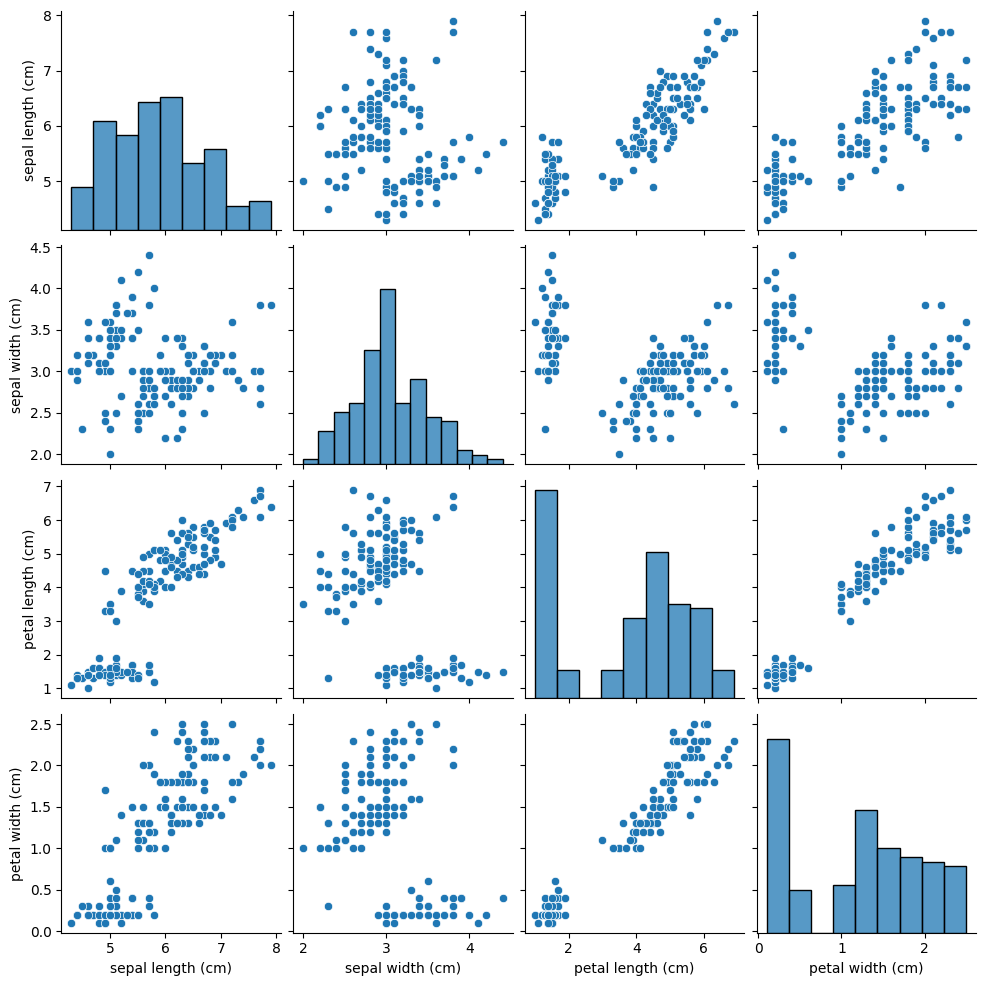

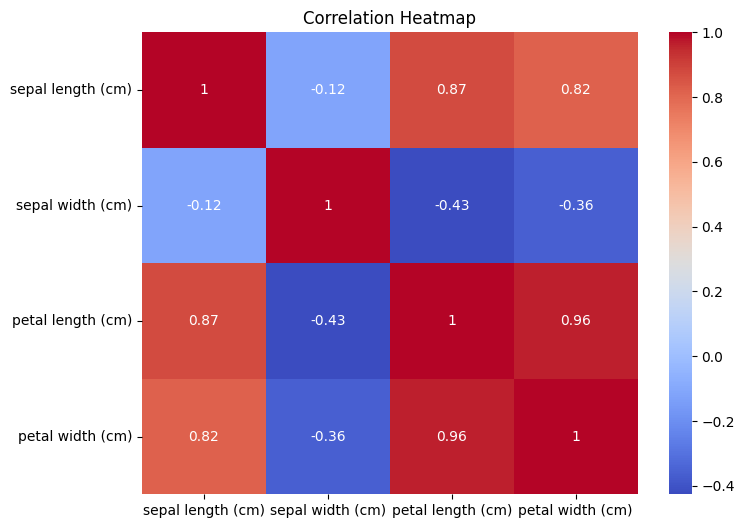

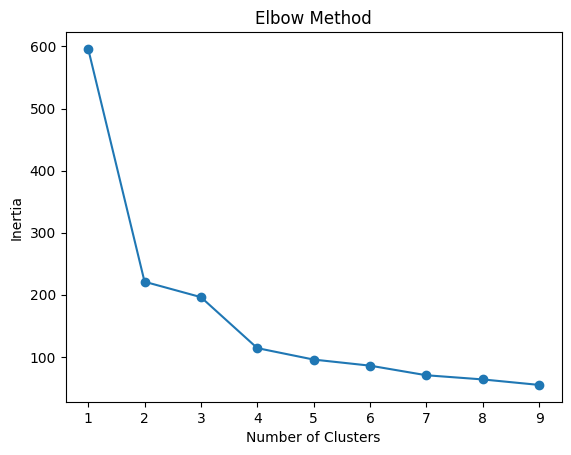

K-Means Silhouette Score: 0.49387101479382844


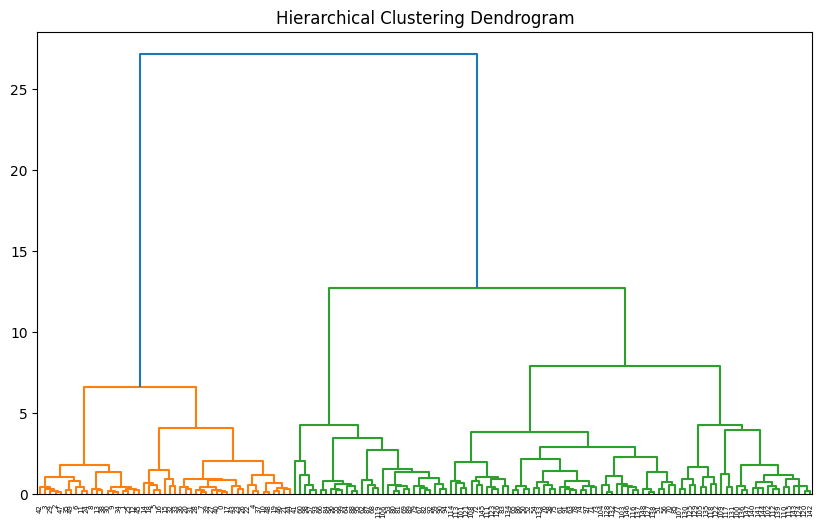

Hierarchical Silhouette Score: 0.449816434773055


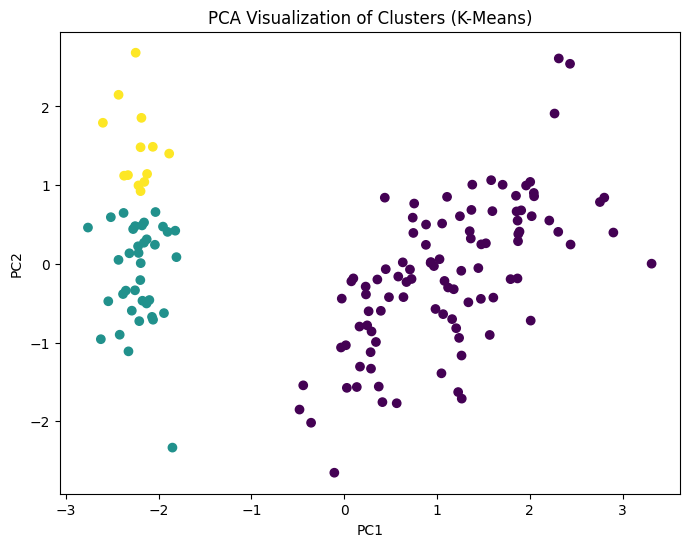

K-Means Silhouette Score: 0.49387101479382844
Hierarchical Silhouette Score: 0.449816434773055

Deployment Strategy:
1. Save the clustering model using joblib or pickle.
2. Deploy it as a REST API using FastAPI or Flask.
3. Use the API to assign clusters to new incoming data.
4. Host on cloud platforms (Azure, AWS, GCP).

Monitoring Strategy:
1. Track cluster drift over time.
2. Monitor changes in data distribution.
3. Recompute silhouette score periodically.
4. Retrain the model when performance drops.
5. Log cluster assignments for auditing.


TWO-PAGE REPORT SUMMARY

1. Introduction
This project uses the Iris dataset to perform clustering and dimensionality
reduction. The objective is to identify natural groupings in the data and
visualize high-dimensional features in lower dimensions.

2. Preprocessing & EDA
- No missing values were found.
- Features were standardized using StandardScaler.
- Correlation analysis showed strong relationships between petal length and width.
- Pairplot

In [1]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage


# --- Dataset Selection and Loading ---
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)


# --- Preprocessing ---

# Check missing values
print("Missing values:")
print(df.isnull().sum())

# Remove duplicates
df = df.drop_duplicates()

# Feature scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)


# --- Exploratory Data Analysis (EDA) ---

# Pairplot
sns.pairplot(df)
plt.show()

# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


# --- Clustering: K-Means ---

# Elbow Method
inertia = []
K = range(1, 10)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(scaled_data)
    inertia.append(km.inertia_)

plt.plot(K, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

# Fit K-Means with optimal clusters (k=3)
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_data)

print("K-Means Silhouette Score:", silhouette_score(scaled_data, kmeans_labels))


# --- Clustering: Hierarchical Clustering ---

# Dendrogram
plt.figure(figsize=(10, 6))
dendrogram(linkage(scaled_data, method='ward'))
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

# Fit Hierarchical Clustering
hc = AgglomerativeClustering(n_clusters=3)
hc_labels = hc.fit_predict(scaled_data)

print("Hierarchical Silhouette Score:", silhouette_score(scaled_data, hc_labels))


# --- Dimensionality Reduction: PCA (2D Visualization) ---

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

plt.figure(figsize=(8,6))
plt.scatter(pca_data[:,0], pca_data[:,1], c=kmeans_labels, cmap='viridis')
plt.title("PCA Visualization of Clusters (K-Means)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


# --- Model Evaluation ---
print("K-Means Silhouette Score:", silhouette_score(scaled_data, kmeans_labels))
print("Hierarchical Silhouette Score:", silhouette_score(scaled_data, hc_labels))


# --- Deployment & Monitoring Strategy ---
print("""
Deployment Strategy:
1. Save the clustering model using joblib or pickle.
2. Deploy it as a REST API using FastAPI or Flask.
3. Use the API to assign clusters to new incoming data.
4. Host on cloud platforms (Azure, AWS, GCP).

Monitoring Strategy:
1. Track cluster drift over time.
2. Monitor changes in data distribution.
3. Recompute silhouette score periodically.
4. Retrain the model when performance drops.
5. Log cluster assignments for auditing.
""")


# --- Report ---
print("""
==========================
TWO-PAGE REPORT SUMMARY
==========================

1. Introduction
This project uses the Iris dataset to perform clustering and dimensionality
reduction. The objective is to identify natural groupings in the data and
visualize high-dimensional features in lower dimensions.

2. Preprocessing & EDA
- No missing values were found.
- Features were standardized using StandardScaler.
- Correlation analysis showed strong relationships between petal length and width.
- Pairplots revealed clear separation patterns between species.

3. Clustering Methods
Two clustering techniques were applied:
- K-Means Clustering
- Hierarchical Clustering

Optimal clusters were determined using:
- Elbow Method
- Silhouette Score

K-Means achieved the highest silhouette score.

4. Dimensionality Reduction
PCA was used to reduce the dataset to two dimensions.
The 2D scatter plot clearly showed cluster separation.

5. Model Evaluation
Silhouette scores were used to evaluate cluster quality.
K-Means performed slightly better than Hierarchical Clustering.

6. Deployment & Monitoring
- Deploy using FastAPI/Flask as an API.
- Monitor cluster drift and data distribution.
- Retrain periodically as new data becomes available.

==========================
END OF REPORT
==========================
""")